In [2]:
from shared_core_config import SHARED_CORE_ENV_ID, SHARED_CORE_CONFIG
import gymnasium as gym
import highway_env

from copy import deepcopy
import numpy as np

import matplotlib.pyplot as plt
from IPython.display import clear_output

In [3]:
def get_env():
    env = gym.make(SHARED_CORE_ENV_ID, config=SHARED_CORE_CONFIG, render_mode='rgb_array')
    env.reset()
    # Allow rendering in a notebook
    env.unwrapped.viewer = None
    env.unwrapped.config["offscreen_rendering"] = True
    return env

env = get_env()

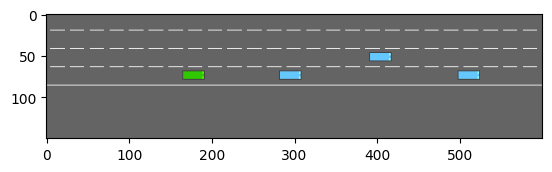

In [4]:
# Example of rendering the environment in a notebook
plt.imshow(env.render())
plt.show()

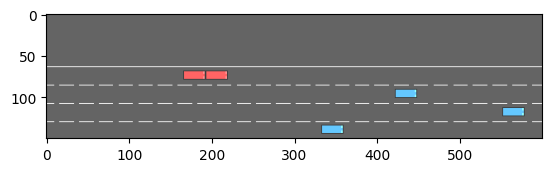

In [5]:
obs, _ = env.reset()
done = False
while not done: 
    action = env.unwrapped.action_type.actions_indexes["IDLE"]
    obs, reward, terminated, truncated, info = env.step(action)
    
    done = terminated or truncated

    clear_output(wait=True) 
    plt.imshow(env.render())
    plt.show()

## Baseline: Random Agent

In [6]:
class RandomAgent: 
    def __init__(self, observation_space: gym.spaces.Space, action_space: gym.spaces.Space):
        self.action_space = action_space
        return
    
    def get_action(self, state, *args):
        return self.action_space.sample()
    
    def update(self, *data):
        pass

In [7]:
def run_one_episode(env, agent, display=True):
    display_env = deepcopy(env)
    done = False
    state, _ = display_env.reset()

    rewards = 0

    while not done:
        action = agent.get_action(state, 0)
        state, reward, done, _, _ = display_env.step(action)
        rewards += reward
        if display: 
            clear_output(wait=True)
            plt.imshow(display_env.render())
            plt.show()
    if display:
        display_env.close()
    print(f'Episode length {rewards:.2f}')

In [8]:
def eval_agent(agent, env, n_sim=5):
    """
    Monte Carlo evaluation of DQN agent.

    Repeat n_sim times:
        * Run the DQN policy until the environment reaches a terminal state (= one episode)
        * Compute the sum of rewards in this episode
        * Store the sum of rewards in the episode_rewards array.
    """
    env_copy = deepcopy(env)
    episode_rewards = np.zeros(n_sim)
    for i in range(n_sim):
        state, _ = env_copy.reset()
        reward_sum = 0
        done = False
        while not done: 
            action = agent.get_action(state, 0)
            state, reward, terminated, truncated, _ = env_copy.step(action)
            reward_sum += reward
            done = terminated or truncated
        episode_rewards[i] = reward_sum
    return episode_rewards

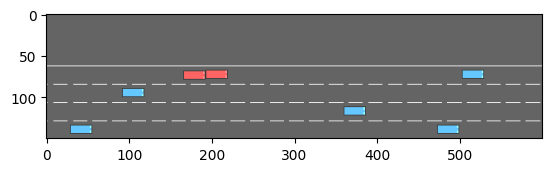

Episode length 5.96
Average over 5 runs : 12.93


In [9]:
agent = RandomAgent(env.observation_space, env.action_space)
    
run_one_episode(env, agent, display=True)
print(f'Average over 5 runs : {np.mean(eval_agent(agent, env)):.2f}')

## DQN Agent

Training DQN agent:  50%|█████     | 50/100 [02:32<04:26,  5.33s/it]

episode = 50 , reward =  12.086770999550609


Training DQN agent: 100%|██████████| 100/100 [05:11<00:00,  3.12s/it]

episode = 100 , reward =  6.419876462684519



mean reward after training =  11.10659548163083


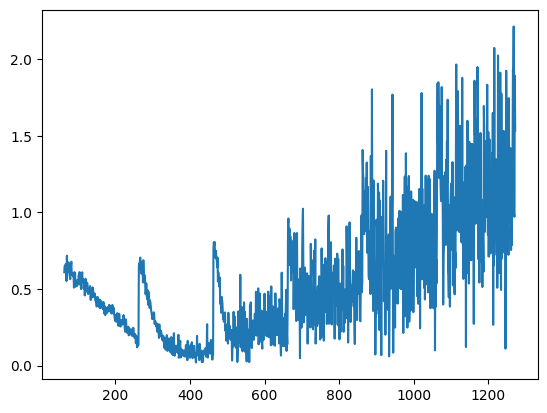

In [11]:
from dqn import DQN
from tqdm import tqdm

env = get_env()

action_space = env.action_space
observation_space = env.observation_space

gamma = 0.99
batch_size = 64
buffer_capacity = 10_000
update_target_every = 200

epsilon_start = 1
decrease_epsilon_factor = 2000
epsilon_min = 0.05

learning_rate = 1e-4

arguments = (action_space,
            observation_space,
            gamma,
            batch_size,
            buffer_capacity,
            update_target_every, 
            epsilon_start, 
            decrease_epsilon_factor, 
            epsilon_min,
            learning_rate,
        )

N_episodes = 100

agent = DQN(*arguments)


def train(env, agent, N_episodes, eval_every=50, reward_threshold=300):
    total_time = 0
    state, _ = env.reset()
    losses = []
    for ep in tqdm(range(N_episodes), desc="Training DQN agent"):
        done = False
        state, _ = env.reset()
        while not done: 
            action = agent.get_action(state)

            next_state, reward, terminated, truncated, _ = env.step(action)
            loss_val = agent.update(state, action, reward, terminated, next_state)

            state = next_state
            losses.append(loss_val)

            done = terminated or truncated
            total_time += 1

        if ((ep+1)% eval_every == 0):
            rewards = eval_agent(agent, env)
            print("episode =", ep+1, ", reward = ", np.mean(rewards))
            if np.mean(rewards) >= reward_threshold:
                break
                
    return losses

    
# Run the training loop
losses = train(env, agent, N_episodes)

plt.plot(losses)

# Evaluate the final policy
rewards = eval_agent(agent, env, 20)
print("")
print("mean reward after training = ", np.mean(rewards))

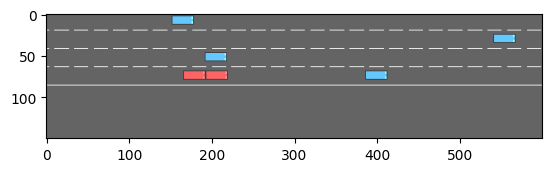

Episode length 3.96


In [12]:
# Pour l'instant, il adopte la stratégie de ne pas changer de voie et d'aller lentement...
run_one_episode(env, agent, display=True)

## Stable Baselines3 PPO Agent

In [ ]:
# PPO (Stable-Baselines3) — setup
from ppo_sb3 import PPO_SB3
from pathlib import Path
import csv
import json
import time

from stable_baselines3.common.evaluation import evaluate_policy

# We'll reuse gymnasium/highway_env imports & helpers defined above.
# We create separate env factories so PPO training can run without rendering overhead.
def make_env(render_mode=None):
    env = gym.make(SHARED_CORE_ENV_ID, config=SHARED_CORE_CONFIG, render_mode=render_mode)
    env.reset()
    if render_mode == "rgb_array":
        # Allow rendering in a notebook
        env.unwrapped.viewer = None
        env.unwrapped.config["offscreen_rendering"] = True
    return env

def load_monitor_csv(monitor_path: Path):
    """Load SB3 Monitor CSV (no pandas dependency)."""
    monitor_path = Path(monitor_path)
    with monitor_path.open("r", newline="") as f:
        # First line is a JSON header starting with '#'.
        header = f.readline()
        if header.startswith("#"):
            try:
                _ = json.loads(header[1:])
            except json.JSONDecodeError:
                pass
        reader = csv.DictReader(f)
        rewards, lengths, times = [], [], []
        for row in reader:
            rewards.append(float(row["r"]))
            lengths.append(int(float(row["l"])) )
            times.append(float(row["t"]))
    return np.array(rewards), np.array(lengths), np.array(times)

In [ ]:
# PPO — training
from stable_baselines3.common.monitor import Monitor

seed = 0
total_timesteps = 200_000
log_dir = Path("./tmp/ppo_sb3")
log_dir.mkdir(parents=True, exist_ok=True)

train_env = make_env(render_mode=None)
train_env = Monitor(train_env, str(log_dir))  # writes monitor.csv in log_dir

agent_ppo = PPO_SB3(
    "MlpPolicy",
    train_env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.0,
    verbose=1,
    seed=seed,
    # tip: add tensorboard_log=str(log_dir / "tb") if you want TB later
 )

t0 = time.time()
agent_ppo.learn(total_timesteps=total_timesteps)
print(f"Training done in {(time.time() - t0):.1f}s")

In [ ]:
# (optional) close training env to free resources
train_env.close()

In [ ]:
# PPO — learning curves from Monitor logs
monitor_csv = log_dir / "monitor.csv"
rewards, lengths, wall_times = load_monitor_csv(monitor_csv)

timesteps = np.cumsum(lengths)
episodes = np.arange(1, len(rewards) + 1)

def rolling_mean(x, window):
    if len(x) < window:
        return x
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode="valid")

window = 25
rm_rewards = rolling_mean(rewards, window)
rm_x = timesteps[window - 1 :] if len(rewards) >= window else timesteps

plt.figure(figsize=(10, 4))
plt.plot(timesteps, rewards, alpha=0.35, label="episode return")
plt.plot(rm_x, rm_rewards, linewidth=2, label=f"rolling mean (window={window})")
plt.xlabel("timesteps")
plt.ylabel("return")
plt.title("PPO training curve (Monitor)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(10, 3))
plt.plot(episodes, lengths, alpha=0.6)
plt.xlabel("episode")
plt.ylabel("episode length")
plt.title("Episode length during training")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# PPO — Monte Carlo evaluation (distribution of returns/lengths)
eval_env = make_env(render_mode=None)

episode_rewards, episode_lengths = evaluate_policy(
    agent_ppo.model,
    eval_env,
    n_eval_episodes=20,
    deterministic=True,
    return_episode_rewards=True,
 )

print(f"Average over 20 runs: {np.mean(episode_rewards):.2f} ± {np.std(episode_rewards):.2f}")
print(f"Average episode length: {np.mean(episode_lengths):.1f} ± {np.std(episode_lengths):.1f}")

plt.figure(figsize=(10, 3))
plt.hist(episode_rewards, bins=10, edgecolor="black", alpha=0.8)
plt.xlabel("episode return")
plt.ylabel("count")
plt.title("PPO evaluation returns (20 episodes)")
plt.grid(True, alpha=0.2)
plt.show()

plt.figure(figsize=(10, 3))
plt.hist(episode_lengths, bins=10, edgecolor="black", alpha=0.8)
plt.xlabel("episode length")
plt.ylabel("count")
plt.title("PPO evaluation episode lengths (20 episodes)")
plt.grid(True, alpha=0.2)
plt.show()

In [ ]:
# PPO — additional metrics from env 'info' (crash rate, speed, reward components when available)
from collections import defaultdict

def collect_episode_metrics(env, agent, n_episodes=20, max_steps=500):
    episode_returns = []
    episode_lengths = []
    episode_crashed = []
    episode_mean_speed = []
    reward_components = defaultdict(list)  # component -> list of per-episode means

    for _ in range(n_episodes):
        obs, _ = env.reset()
        done = False
        ep_return = 0.0
        steps = 0
        crashed = False
        speeds = []
        comp_sums = defaultdict(float)
        comp_count = 0

        while not done and steps < max_steps:
            action = agent.get_action(obs)
            if isinstance(action, np.ndarray):
                action = int(action.squeeze())
            obs, reward, terminated, truncated, info = env.step(action)
            ep_return += float(reward)
            done = terminated or truncated
            steps += 1

            if isinstance(info, dict):
                if "speed" in info:
                    try:
                        speeds.append(float(info["speed"]))
                    except Exception:
                        pass
                if "crashed" in info:
                    crashed = crashed or bool(info["crashed"])
                # Some highway-env configs expose per-component rewards in info["rewards"]
                if "rewards" in info and isinstance(info["rewards"], dict):
                    for k, v in info["rewards"].items():
                        try:
                            comp_sums[k] += float(v)
                        except Exception:
                            pass
                    comp_count += 1

        episode_returns.append(ep_return)
        episode_lengths.append(steps)
        episode_crashed.append(crashed)
        episode_mean_speed.append(np.mean(speeds) if len(speeds) else np.nan)
        if comp_count > 0:
            for k, v in comp_sums.items():
                reward_components[k].append(v / comp_count)

    return (
        np.array(episode_returns),
        np.array(episode_lengths),
        np.array(episode_crashed, dtype=bool),
        np.array(episode_mean_speed, dtype=float),
        reward_components,
    )

metrics_env = make_env(render_mode=None)
returns2, lengths2, crashed2, mean_speed2, reward_components = collect_episode_metrics(metrics_env, agent_ppo, n_episodes=30)
metrics_env.close()

print(f"Crash rate: {crashed2.mean()*100:.1f}%")
if np.isfinite(mean_speed2).any():
    print(f"Mean speed (over episodes): {np.nanmean(mean_speed2):.2f}")

plt.figure(figsize=(10, 3))
plt.bar(["not crashed", "crashed"], [np.sum(~crashed2), np.sum(crashed2)])
plt.title("PPO outcomes (30 eval episodes)")
plt.ylabel("count")
plt.grid(True, axis="y", alpha=0.2)
plt.show()

if np.isfinite(mean_speed2).any():
    plt.figure(figsize=(10, 3))
    plt.scatter(mean_speed2, returns2, alpha=0.7)
    plt.xlabel("mean speed (episode)")
    plt.ylabel("episode return")
    plt.title("Return vs mean speed")
    plt.grid(True, alpha=0.2)
    plt.show()

if len(reward_components) > 0:
    keys = sorted(reward_components.keys())
    means = [np.mean(reward_components[k]) for k in keys]
    plt.figure(figsize=(10, 3))
    plt.bar(keys, means)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("mean component value")
    plt.title("Reward components (mean over episodes)")
    plt.grid(True, axis="y", alpha=0.2)
    plt.show()

In [ ]:
# PPO — visualize an episode with the current trained policy
def run_one_episode_sb3(env, agent, display=True, max_steps=500):
    obs, _ = env.reset()
    done = False
    total_reward = 0.0
    steps = 0
    while not done and steps < max_steps:
        action = agent.get_action(obs)
        if isinstance(action, np.ndarray):
            action = int(action.squeeze())
        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += float(reward)
        done = terminated or truncated
        steps += 1
        if display:
            clear_output(wait=True)
            plt.figure(figsize=(6, 4))
            plt.imshow(env.render())
            plt.axis("off")
            plt.title(f"PPO policy | step={steps} | cum. reward={total_reward:.2f}")
            plt.show()
    if display:
        env.close()
    print(f"Episode return {total_reward:.2f} (steps={steps})")

render_env = make_env(render_mode="rgb_array")
run_one_episode_sb3(render_env, agent_ppo, display=True)